In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scarf

scarf.configure_output(level='WARNING', progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_8K_pbmc_citeseq',
    destination='scarf_datasets',
    zarr=True,
)

In [2]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    default_assay='RNA',
    nthreads=4
)
ds

DataStore has 7549 (7865) cells with 2 assays: ADT RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'ADT_nFeatures', 
            'ADT_UMAP1', 'RNA_tSNE1', 'RNA_percentRibo', 'RNA_tSNE2', 'ADT_nCounts', 
            'ADT_UMAP2', 'RNA_UMAP1', 'RNA_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_leiden_cluster', 'ADT_leiden_cluster', 'RNA_UMAP2'
   ADT assay has 14 (17) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          
   RNA assay has 13550 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
            'I__hvgs'

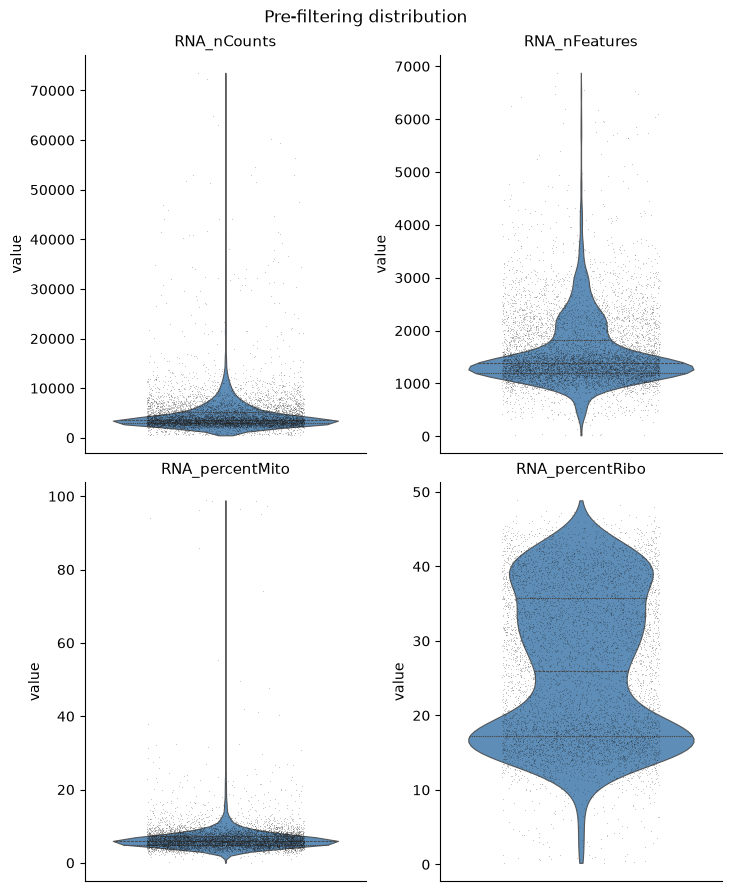

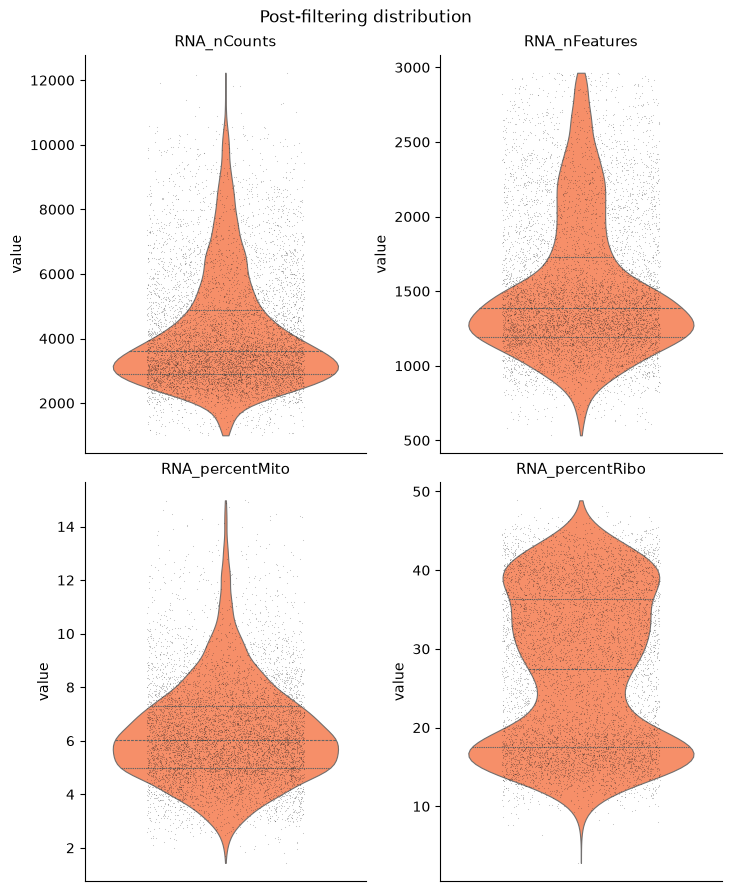

In [3]:
ds.auto_filter_cells()

In [4]:
ds.mark_hvgs(
    min_cells=20,
    top_n=1000,
    min_mean=-3,
    max_mean=2,
    max_var=6,
    show_plot=False,
)

ds.run_normalization(feat_key='hvgs')
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=21)
ds.build_connectivity_map()

ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)
ds.run_leiden_clustering(resolution=1)
ds.load_graph()

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 154182 stored elements and shape (7342, 7342)>

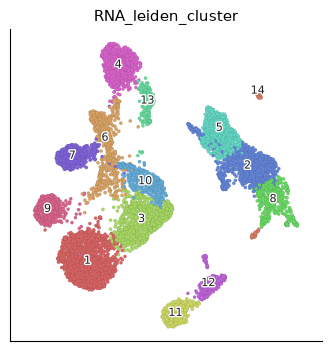

In [5]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [6]:
ds.ADT.normMethod.__name__

'norm_clr'

In [7]:
adt_panel = ds.ADT.feats.to_pandas_dataframe(['names'])
adt_panel['is_control'] = adt_panel['names'].str.contains('control')
adt_panel[adt_panel['is_control']]

,names,is_control
14,IgG2a_control_TotalSeqB,True
15,IgG1_control_TotalSeqB,True
16,IgG2b_control_TotalSeqB,True


In [8]:
ds.ADT.feats.update_key(~adt_panel['is_control'].values, 'I')
print(
    f"Active ADT features: {int(ds.ADT.feats.fetch_all('I').sum())}"
    f" of {len(adt_panel)}"
)

Active ADT features: 14 of 17


In [9]:
normalized_adt = ds.run_normalization(from_assay='ADT', feat_key='I')
n_adt_features = int(ds.load_artifact(normalized_adt)['data'].shape[1])
ds.run_custom_reduction(
    np.eye(n_adt_features, dtype=np.float64),
    normalized_adt,
    from_assay='ADT',
)
ds.build_embedding_initialization(from_assay='ADT', n_centroids=100)
ds.build_ann_index(from_assay='ADT')
ds.query_neighbors(from_assay='ADT', k=21)
ds.build_connectivity_map(from_assay='ADT')

ArtifactRef(assay='ADT', kind='connectivity_map', artifact_id='3310f07f77f4...')

In [10]:
ds.run_umap(
    from_assay='ADT',
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)
ds.run_leiden_clustering(
    from_assay='ADT',
    resolution=1
)

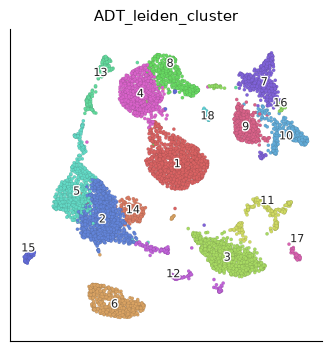

In [11]:
ds.plots.embedding(
    layout_key='ADT_UMAP',
    color_by='ADT_leiden_cluster',
)

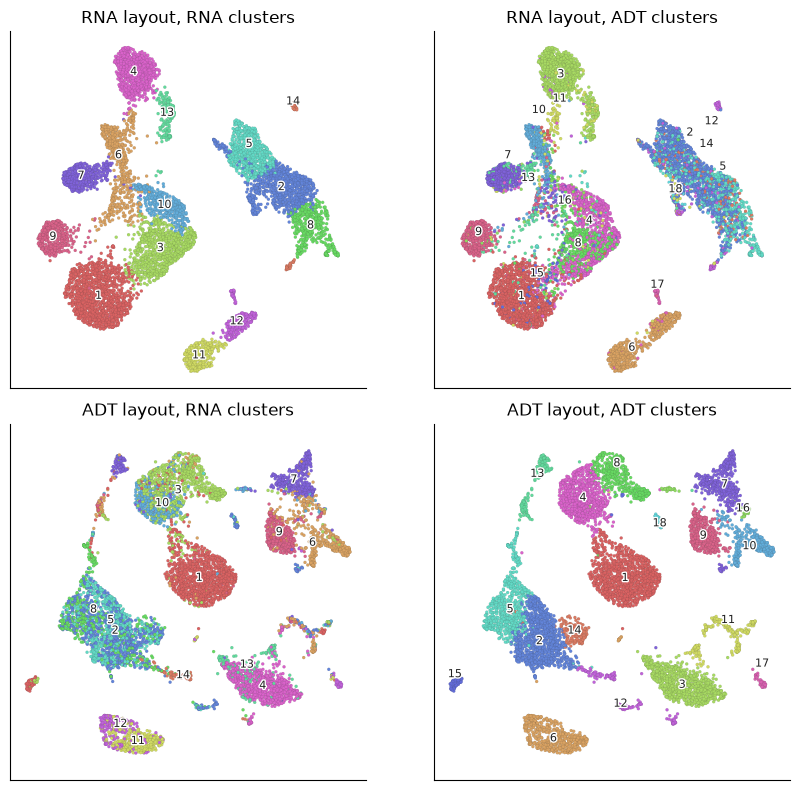

In [12]:
figure, axes = plt.subplots(2, 2, figsize=(9, 8))
modality_panels = (
    ("RNA layout, RNA clusters", "RNA_UMAP", "RNA_leiden_cluster"),
    ("RNA layout, ADT clusters", "RNA_UMAP", "ADT_leiden_cluster"),
    ("ADT layout, RNA clusters", "ADT_UMAP", "RNA_leiden_cluster"),
    ("ADT layout, ADT clusters", "ADT_UMAP", "ADT_leiden_cluster"),
)
for axis, (title, layout_key, color_by) in zip(
    axes.flat, modality_panels, strict=True
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by=color_by,
        point_size=5,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()

In [13]:
ds.integrate_assays(
    assays=['RNA', 'ADT'],
    label='RNA+ADT',
    method='snn',
)

In [14]:
ds.run_umap(
    integrated_graph='RNA+ADT',
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True
)
ds.run_leiden_clustering(
    integrated_graph='RNA+ADT',
    resolution=1.75
)

/tmp/ipykernel_921150/2692770943.py:19: UserWarning: The figure layout has changed to tight
  snn_comparison.figure.tight_layout()


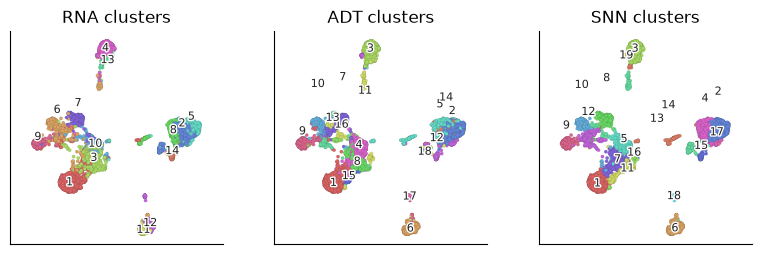

In [15]:
snn_comparison = ds.plots.embedding(
    layout_key='RNA+ADT_UMAP',
    color_by=[
        'RNA_leiden_cluster',
        'ADT_leiden_cluster',
        'RNA+ADT_leiden_cluster',
    ],
    legend_loc='on_data',
    n_columns=3,
    show_titles=False,
    show=False,
)
for axis, title in zip(
    snn_comparison.axes.values(),
    ("RNA clusters", "ADT clusters", "SNN clusters"),
    strict=True,
):
    axis.set_title(title)
snn_comparison.figure.tight_layout()

In [16]:
ds.integrate_assays(
    assays=['RNA', 'ADT'],
    label='RNA+ADT_wnn',
    method='wnn'
)
ds.run_umap(
    integrated_graph='RNA+ADT_wnn',
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True
)
ds.run_leiden_clustering(
    integrated_graph='RNA+ADT_wnn',
    resolution=1.75
)

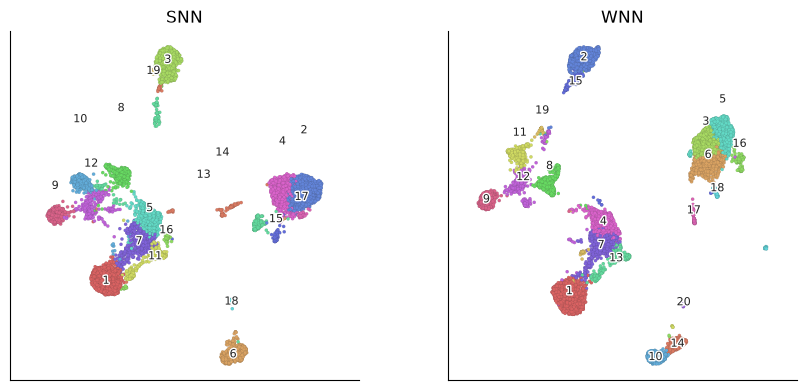

In [17]:
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
integration_panels = (
    ("SNN", "RNA+ADT_UMAP", "RNA+ADT_leiden_cluster"),
    ("WNN", "RNA+ADT_wnn_UMAP", "RNA+ADT_wnn_leiden_cluster"),
)
for axis, (title, layout_key, color_by) in zip(
    axes, integration_panels, strict=True
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by=color_by,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()